In [2]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import matplotlib as mpl
from astropy import units
from astropy import constants as const
from matplotlib.patches import Rectangle
from matplotlib.animation import FuncAnimation
from  IPython.display import HTML
from scipy.optimize import curve_fit
from scipy.special import wofz
from scipy.interpolate import interp1d


mpl.rcParams['font.size'] = 14
mpl.rcParams['image.cmap']="Greys_r" 
mpl.rcParams['image.origin']= "lower"

In [3]:
sst4 = h5py.File("/mn/stornext/d19/RoCS/svenwe/lecture/AST5770/data/obssun_sst4/obssun_sst4.h5", "r")
intensity = sst4["intensity"][:]
wavelength = sst4["wavelength"][:]
time = sst4["time"][:]
time_s = sst4["time_s"][:]
x = sst4["x"][:]
y = sst4["y"][:]
c = const.c

In [4]:
# finding central wavelength of Fe I line
FeI = np.mean(wavelength)
thr = 1e-3
search = np.logical_and(wavelength > FeI - thr, wavelength < FeI + thr)
line_core_idx = np.where(search == True)[0][0]
central_lmbda = wavelength[line_core_idx]
print(f"Line core index: {line_core_idx}")
print(f"Central wavelength of Fe I line: {central_lmbda} nm")

Line core index: 7
Central wavelength of Fe I line: 617.3367919921875 nm


In [5]:
subfield_A = sst4["intensity"][:, :, 394:481, 394:481]
x_subfield_A = sst4["x"][394:481]; y_subfield_A = sst4["y"][394:481]
subfield_B = sst4["intensity"][:, :, 118:204, 118:204]
x_subfield_B = sst4["x"][118:204]; y_subfield_B = sst4["y"][118:204]

xy_A_min = 394; xy_A_max = 481
xy_B_min = 118; xy_B_max =  204

In [6]:
def _voigt(x, amplitude, center, sigma, gamma, background):
    z = ((x - center) + 1j * gamma) / (sigma * np.sqrt(2))
    return amplitude * np.real(wofz(z)) / (sigma * np.sqrt(2 * np.pi)) + background

In [7]:
def _fit_voigt(x_data, y_data, nump, thr):
    # Create the interpolator using linear interpolation
    interpolator = interp1d(x_data, y_data, kind='linear')

    # Use the interpolator to compute y values at new x points
    x_interpolated = np.linspace(x_data.min(), x_data.max(), nump)
    y_interpolated = interpolator(x_interpolated)

    # Parameters for curve fit
    background_level_guess = np.max(y_data)                             # Baseline level
    amplitude_guess = - (np.max(y_data) - np.min(y_data))    # Dip depth
    mean_guess = np.mean(wavelength)                                               # Center of the dip

    # Find FWHM
    peak_max = np.max(y_data) - np.min(y_data)
    half_max = peak_max / 2 + np.min(y_data)
    indices = np.logical_and(y_interpolated > half_max - thr, y_interpolated < half_max + thr)
    search = np.where(indices == True)[0]
    if search.size < 2:
        print("No FWHM found")
    fwhm = x_interpolated[search[-1]] - x_interpolated[search[0]]
    sigma_guess =  fwhm       # Width of the Gaussian component
    gamm_guess = sigma_guess          # Width of the Lorentzian component

    # Initial guesses for curve fitting parameters
    initial_guesses = [amplitude_guess, mean_guess, sigma_guess, gamm_guess, background_level_guess]

    # Fit the Voigt profile
    popt, pcov = curve_fit(_voigt, x_interpolated, y_interpolated, p0=initial_guesses, maxfev=5000)
    return x_interpolated, _voigt(x_interpolated, *popt)

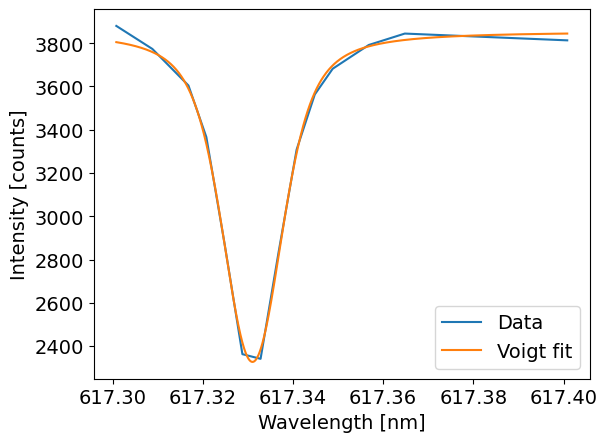

In [8]:
A_intensity_avg = np.average(subfield_A, axis=(0, 2, 3))
x_voigt, A_voigt_avg = _fit_voigt(wavelength, A_intensity_avg, nump = 1000, thr = 5)
plt.plot(wavelength, A_intensity_avg, label="Data")
plt.plot(x_voigt, A_voigt_avg, label="Voigt fit")


plt.xlabel("Wavelength [nm]")
plt.ylabel("Intensity [counts]")
plt.legend()
plt.show()

302
Line center wavelength: 617.3310651349592 nm


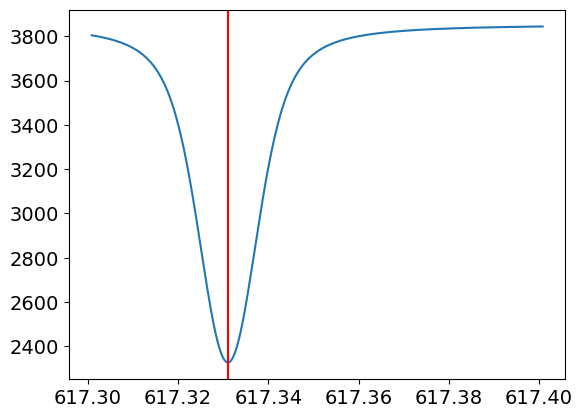

In [9]:
line_center = np.where(A_voigt_avg == np.min(A_voigt_avg))[0][0]
print(line_center)
line_center_wavelength = x_voigt[line_center]
print(f"Line center wavelength: {line_center_wavelength} nm")
plt.plot(x_voigt, A_voigt_avg, label="Voigt fit")
plt.axvline(x=line_center_wavelength, color="red", label="Line center")

Peak value: 3793.8990391691627


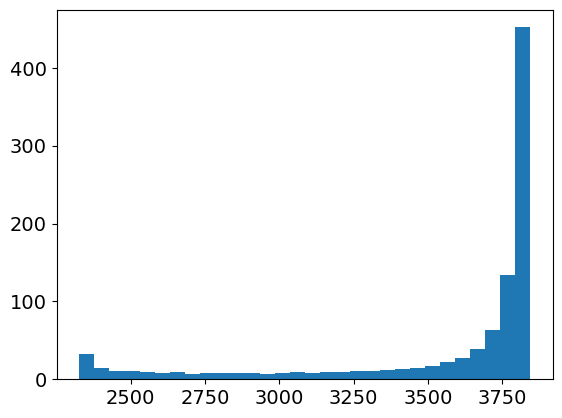

In [10]:
counts, bin_edges = np.histogram(A_voigt_avg, bins=30)

max_count_index = np.argmax(counts)
peak_value = bin_edges[max_count_index]
print(f"Peak value: {peak_value}")

plt.figure()
plt.hist(A_voigt_avg, bins=30);

In [11]:
print(f"Wavelength range: {x_voigt[0]} - {x_voigt[-1]} nm")
print(f"Line center wavelength: {line_center_wavelength} nm")

cut_off_min = 0

for wav in x_voigt[:line_center]:
    wav_idx = np.where(x_voigt == wav)[0][0]
    if A_voigt_avg[wav_idx] < peak_value:
        cut_off_min = wav_idx
        break

cut_off_max = 0
for wav in x_voigt[line_center:]:
    wav_idx = np.where(x_voigt == wav)[0][0]
    if A_voigt_avg[wav_idx] < peak_value:
        cut_off_max = wav_idx

Wavelength range: 617.3008422851562 - 617.4008178710938 nm
Line center wavelength: 617.3310651349592 nm


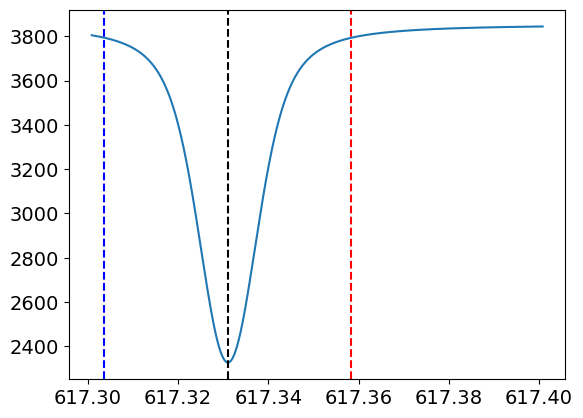

In [12]:
plt.plot(x_voigt, A_voigt_avg, label="Voigt fit")
plt.axvline(x=line_center_wavelength, color="k", ls = '--', label="Line center")
plt.axvline(x=x_voigt[cut_off_min], color="b", ls='--', label="Lower bound")
plt.axvline(x=x_voigt[cut_off_max], color="r", ls='--', label="Upper bound")

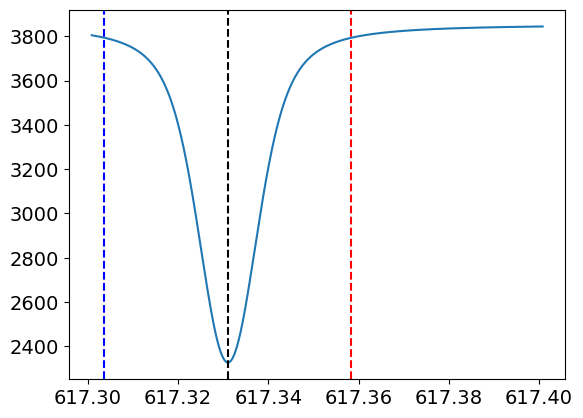

In [13]:
cut_off_min = 0

for wav in x_voigt[:line_center]:
    wav_idx = np.where(x_voigt == wav)[0][0]
    if A_voigt_avg[wav_idx] < peak_value:
        cut_off_min = wav_idx
        break

cut_off_max = 0
for wav in x_voigt[line_center:][::-1]:

    wav_idx = np.where(x_voigt == wav)[0][0]
    if A_voigt_avg[wav_idx] < peak_value:
        cut_off_max = wav_idx
        break
        
plt.plot(x_voigt, A_voigt_avg, label="Voigt fit")
plt.axvline(x=line_center_wavelength, color="k", ls = '--', label="Line center")
plt.axvline(x=x_voigt[cut_off_min], color="b", ls='--', label="Lower bound")
plt.axvline(x=x_voigt[cut_off_max], color="r", ls='--', label="Upper bound")

In [14]:
def int_range(intensity_data, wavelengths):
    counts, bin_edges = np.histogram(intensity_data, bins=30)
    max_count_index = np.argmax(counts)
    peak_intensity_value = bin_edges[max_count_index]

    line_center_idx = np.where(intensity_data == np.min(intensity_data))[0][0]
    line_center_wavelength = wavelengths[line_center_idx]

    cut_off_min = 0

    for wav in x_voigt[:line_center_idx]:
        wav_idx = np.where(wavelengths == wav)[0][0]
        if intensity_data[wav_idx] < peak_intensity_value:
            cut_off_min = wav_idx
            break

    cut_off_max = 0
    for wav in x_voigt[line_center_idx:][::-1]:
        wav_idx = np.where(wavelengths == wav)[0][0]
        if intensity_data[wav_idx] < peak_intensity_value:
            cut_off_max = wav_idx
            break

    return cut_off_min, cut_off_max, line_center_idx, peak_intensity_value

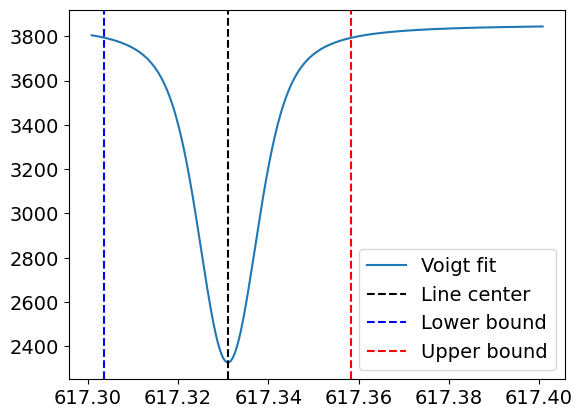

In [15]:
mi, ma, cent, I_cont = int_range(A_voigt_avg, x_voigt)
plt.plot(x_voigt, A_voigt_avg, label="Voigt fit")
plt.axvline(x=x_voigt[cent], color="k", ls = '--', label="Line center")
plt.axvline(x=x_voigt[mi], color="b", ls='--', label="Lower bound")
plt.axvline(x=x_voigt[ma], color="r", ls='--', label="Upper bound")
plt.legend()

In [16]:
test_data = np.average(subfield_A, axis=(2, 3))

nump = 1000
wavs = np.linspace(wavelength.min(), wavelength.max(), nump)
temp_avg = np.zeros((len(time_s), nump))
for t in range(len(time_s)):
    x_voigt, A_voigt_avg = _fit_voigt(wavelength, test_data[t, :], nump = nump, thr = 7)
    temp_avg[t] = A_voigt_avg
    # plt.plot(x_voigt, A_voigt_avg, label="Voigt fit")

arr = np.zeros(len(time_s))
for t in range(len(time_s)):
    cut_off_min, cut_off_max, line_center, I_cont = int_range(temp_avg[t], wavs)
    # ew = np.trapz(1 - temp_avg[t][cut_off_min:cut_off_max] / I_cont, wavs[cut_off_min:cut_off_max])*units.nm
    ew = np.trapz( (I_cont - temp_avg[t][cut_off_min:cut_off_max]) / I_cont, wavs[cut_off_min:cut_off_max])*units.nm
    print(ew.to(units.mAA))
    arr[t] = ew.to(units.mAA).value
    # plt.plot(wavs, temp_avg[t], label=f"{time_s[t]} s")
    # plt.axvline(x=wavs[cut_off_min], color="b", ls='--')
    # plt.axvline(x=wavs[cut_off_max], color="r", ls='--')
    # plt.axvline(x=wavs[line_center], color="k", ls='--')
    # plt.show()

print(np.mean(arr), np.std(arr))
    

/tmp/ipykernel_2312970/3978198344.py:3: RuntimeWarning: overflow encountered in multiply
  return amplitude * np.real(wofz(z)) / (sigma * np.sqrt(2 * np.pi)) + background
/tmp/ipykernel_2312970/3978198344.py:3: RuntimeWarning: overflow encountered in divide
  return amplitude * np.real(wofz(z)) / (sigma * np.sqrt(2 * np.pi)) + background


66.03348416628845 mAngstrom
66.06193306233227 mAngstrom
65.63219598610978 mAngstrom
67.01519024235017 mAngstrom
67.61509714320843 mAngstrom
66.84562709992167 mAngstrom
66.32506854089307 mAngstrom
66.09051862047002 mAngstrom
66.75746579307416 mAngstrom
66.88913734151527 mAngstrom
67.10064529483411 mAngstrom
66.59624085859525 mAngstrom
66.22615172045754 mAngstrom
66.39748814429807 mAngstrom
66.61445986005282 mAngstrom
66.21055271887519 mAngstrom
66.75327922648967 mAngstrom
67.25409390789655 mAngstrom
67.72007077719898 mAngstrom
66.59052422696439 mAngstrom
66.62685095691482 mAngstrom
67.72635946964436 mAngstrom
68.41334939698943 mAngstrom
66.14049406087808 mAngstrom
65.43426298659466 mAngstrom
66.87795646368174 mAngstrom
66.43816147590782 mAngstrom
65.50700481796585 mAngstrom
66.24140384637998 mAngstrom
66.24238685479175 mAngstrom
66.58405547535746 mAngstrom
66.14468492337465 mAngstrom
67.39901072198083 mAngstrom
68.03389980771429 mAngstrom
67.07115151070201 mAngstrom
66.36493707406184 mA

In [17]:
test_data = np.average(subfield_B, axis=(2, 3))

nump = 1000
wavs = np.linspace(wavelength.min(), wavelength.max(), nump)
temp_avg = np.zeros((len(time_s), nump))
for t in range(len(time_s)):
    x_voigt, B_voigt_avg = _fit_voigt(wavelength, test_data[t, :], nump = nump, thr = 7)
    temp_avg[t] = B_voigt_avg
    # plt.plot(x_voigt, A_voigt_avg, label="Voigt fit")

arr = np.zeros(len(time_s))
for t in range(len(time_s)):
    cut_off_min, cut_off_max, line_center, I_cont = int_range(temp_avg[t], wavs)
    # ew = np.trapz(1 - temp_avg[t][cut_off_min:cut_off_max] / I_cont, wavs[cut_off_min:cut_off_max])*units.nm
    ew = np.trapz( (I_cont - temp_avg[t][cut_off_min:cut_off_max]) / I_cont, wavs[cut_off_min:cut_off_max])*units.nm
    print(ew.to(units.mAA))
    arr[t] = ew.to(units.mAA).value
    # plt.plot(wavs, temp_avg[t], label=f"{time_s[t]} s")
    # plt.axvline(x=wavs[cut_off_min], color="b", ls='--')
    # plt.axvline(x=wavs[cut_off_max], color="r", ls='--')
    # plt.axvline(x=wavs[line_center], color="k", ls='--')
    # plt.show()

print(np.mean(arr), np.std(arr))
    

/tmp/ipykernel_2312970/3978198344.py:3: RuntimeWarning: overflow encountered in multiply
  return amplitude * np.real(wofz(z)) / (sigma * np.sqrt(2 * np.pi)) + background
/tmp/ipykernel_2312970/3978198344.py:3: RuntimeWarning: overflow encountered in divide
  return amplitude * np.real(wofz(z)) / (sigma * np.sqrt(2 * np.pi)) + background


97.26641415313564 mAngstrom
97.15692426412636 mAngstrom
96.82645726151779 mAngstrom
96.47216919613243 mAngstrom
96.43965308240772 mAngstrom
95.93633501890133 mAngstrom
96.48915187880249 mAngstrom
96.9891398168334 mAngstrom
97.63493793540223 mAngstrom
96.91172626637315 mAngstrom
141.11196851032733 mAngstrom
141.90379900780178 mAngstrom
95.15422683156186 mAngstrom
96.16631930709296 mAngstrom
111.56746164729574 mAngstrom
97.85008940547233 mAngstrom
98.84940319647215 mAngstrom
99.11265119277006 mAngstrom
97.74948123631819 mAngstrom
96.46820124827263 mAngstrom
95.92080323159902 mAngstrom
96.45478682421776 mAngstrom
97.42001167747401 mAngstrom
98.3960992021301 mAngstrom
98.92346941704591 mAngstrom
99.74596017193699 mAngstrom
97.936606562952 mAngstrom
96.71419572792603 mAngstrom
95.84866958836771 mAngstrom
95.67187786751076 mAngstrom
96.54743989202635 mAngstrom
97.17926805341156 mAngstrom
98.24012073489331 mAngstrom
97.13206587990018 mAngstrom
96.89598643776891 mAngstrom
96.62574538952225 mAn